# 01 — Crawl & Topology

## What the Lightning Network is

Bitcoin's base layer settles roughly seven transactions per second, each waiting about ten minutes for a confirmation, with fees that climb when the chain is busy. Fine for storing value; too slow and costly for buying coffee. The Lightning Network is a payment layer built on top of Bitcoin to fix that.

The unit of Lightning is the **payment channel**. Two parties lock some bitcoin into a shared 2-of-2 address on the Bitcoin chain — that on-chain transaction is the only slow, fee-paying step. Once the channel is open, they pay each other by swapping signed updates to how the locked balance is divided. Those updates are instant, nearly free, and never touch the chain until someone closes the channel. A channel's **capacity** is the total locked in it; the **balance** is how that total is split between the two sides right now.

You don't need a direct channel to everyone you pay. Channels connect into a graph, and a payment can **hop** across several channels — A→B→C→D — with each middle node forwarding it for a small fee. That graph is what this project studies.

## What is public, and what isn't

To route payments, nodes broadcast their channels over a gossip protocol, so the topology — who connects to whom, and each channel's capacity — is public. The **balance split inside each channel is private**. You can see that a channel holds 5,000,000 sat; you can't see whether it's 5M on one side and 0 on the other, or split evenly, and it shifts with every payment. That one asymmetry is the whole theme of notebook 04.

## This notebook

How the data was collected, how complete it is, and the overall shape of the network: how channels are spread across nodes, how capital is spread across channels, and whether the whole thing hangs together as one navigable network. This run's snapshot: **9,990 nodes and 44,501 channels — about 57% of the public network — holding 5,637 BTC (bitcoin).**

In [1]:
%matplotlib inline
import os
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from scipy import stats as sp_stats

from lngraph import config
from lngraph.ingest import ingest
from lngraph.graph import simplify, largest_connected_component
import lngraph.topology as topo

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": "white"})

# Locate project root by climbing until lngraph/ package dir is found.
_here = Path().resolve()
PROJECT_ROOT = _here
while not (PROJECT_ROOT / "lngraph").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

# LNGRAPH_SNAPSHOT_DIR overrides the default snapshot location (set in CI/tests).
_override = os.environ.get("LNGRAPH_SNAPSHOT_DIR")
SNAPSHOT_DIR = Path(_override) if _override else PROJECT_ROOT / "data" / "snapshots"
SNAPSHOT_PATH = SNAPSHOT_DIR / "describegraph.json"

try:
    _disp = SNAPSHOT_PATH.relative_to(PROJECT_ROOT)
except ValueError:
    _disp = SNAPSHOT_PATH
print(f"Snapshot path : {_disp}")

Snapshot path : data/snapshots/describegraph.json


In [2]:
if not SNAPSHOT_PATH.exists():
    raise FileNotFoundError(
        f"No snapshot at {SNAPSHOT_PATH} — run `make crawl` to build one.\n"
        "This notebook requires real Lightning Network data and has no synthetic fallback."
    )

dg = json.loads(SNAPSHOT_PATH.read_text())
print(f"Loaded snapshot: {len(dg['nodes'])} nodes, {len(dg['edges'])} channels")

G = ingest(dg)
G_simple = simplify(G)
G_lcc = largest_connected_component(G)

_ch_ids = {data.get("channel_id") for _, _, data in G.edges(data=True)}
print(f"\nMultiDiGraph  : {G.number_of_nodes():,} nodes  {len(_ch_ids):,} channels")
print(f"LCC           : {G_lcc.number_of_nodes():,} nodes  ({G_lcc.number_of_nodes()/G.number_of_nodes()*100:.1f}% of total)")

Loaded snapshot: 9990 nodes, 44501 channels



MultiDiGraph  : 9,990 nodes  44,501 channels
LCC           : 9,988 nodes  (100.0% of total)


## 1 · How the data was collected

mempool.space has no "download the whole graph" endpoint. The only question you can ask is *"what channels does this one node have?"* — `GET /v1/lightning/channels?public_key=<node>`. So to assemble a graph we **crawl**: start from a handful of known large hubs, list each one's channels, read off the peers on the far side, add any new peers to a queue, and repeat outward. This is breadth-first search over the network, and it's how every node here was discovered.

The crawler is polite and resumable: it limits itself to ~1.5 requests/second, backs off when the API (application programming interface) rate-limits it, caches every response to disk, and persists its frontier so a stopped crawl resumes where it left off. The table below shows the exact settings.

What comes out is the **announced graph as seen over the crawl window** — a real but partial snapshot. The coverage cell that follows compares our totals against mempool's live aggregate. Channel coverage there reads above 100%: expected, not a bug. The per-node endpoint returns live data while the aggregate lags, the crawl spanned hours of network churn, and hubs (crawled first) carry larger-than-average channels.

In [3]:
cfg_rows = [
    ("Base URL",        config.MEMPOOL_BASE_URL),
    ("Seed hubs",       f"{len(config.SEED_PUBKEYS)} pubkeys (top-connectivity hubs, May 2026)"),
    ("Max crawl nodes", f"{config.CRAWL_MAX_NODES:,}"),
    ("Pages / node",    str(config.CRAWL_MAX_PAGES_PER_NODE)),
    ("Rate limit",      f"{config.RATE_LIMIT_CALLS_PER_SEC} req/s"),
    ("Backoff",         f"{config.BACKOFF_BASE_DELAY}s base, {config.BACKOFF_MAX_DELAY}s ceiling"),
    ("Max retries",     str(config.BACKOFF_MAX_RETRIES)),
]
df_cfg = pd.DataFrame(cfg_rows, columns=["Parameter", "Value"])
print(df_cfg.to_string(index=False))

      Parameter                                       Value
       Base URL                   https://mempool.space/api
      Seed hubs 8 pubkeys (top-connectivity hubs, May 2026)
Max crawl nodes                                      17,500
   Pages / node                                          20
     Rate limit                                   1.5 req/s
        Backoff                   2.0s base, 120.0s ceiling
    Max retries                                           6


In [4]:
# Coverage vs the full LN graph (requires live mempool.space access).
try:
    from lngraph.fetch_mempool import fetch_statistics
    stats = fetch_statistics()
    report = topo.coverage_report(G, {"latest": stats})
    print(f"Network total : {stats['node_count']:,} nodes / {stats['channel_count']:,} channels")
    print(f"Crawled       : {report['crawled_nodes']:,} nodes / {report['crawled_channels']:,} channels")
    print(f"Node coverage : {report['node_coverage_pct']:.1f}%")
    print(f"Channel cov.  : {report['channel_coverage_pct']:.1f}%")
    if report["channel_coverage_pct"] > 100:
        print(
            "  Note: >100% channel coverage is expected here, not a bug. The per-node\n"
            "  /channels endpoint returns live data, while /statistics/latest is a lagged\n"
            "  point-in-time aggregate, and this crawl + enrichment spanned hours of live\n"
            "  network churn. Capacity exceeds the aggregate by more than channel count\n"
            "  because hubs (crawled first) carry larger-than-average channels. Treat all\n"
            "  figures as a snapshot of the announced graph over the crawl window."
        )
except Exception as exc:
    print(f"Coverage report unavailable ({type(exc).__name__}: {exc})")

Network total : 17,500 nodes / 41,244 channels
Crawled       : 9,990 nodes / 44,501 channels
Node coverage : 57.1%
Channel cov.  : 107.9%
  Note: >100% channel coverage is expected here, not a bug. The per-node
  /channels endpoint returns live data, while /statistics/latest is a lagged
  point-in-time aggregate, and this crawl + enrichment spanned hours of live
  network churn. Capacity exceeds the aggregate by more than channel count
  because hubs (crawled first) carry larger-than-average channels. Treat all
  figures as a snapshot of the announced graph over the crawl window.


## 2 · Does the network hang together?

A payment can only physically reach a destination if both nodes sit in the same **connected component** — one island of mutually reachable nodes. Two flavours: a **weakly** connected component (WCC) ignores channel direction; a **strongly** connected component (SCC) requires a directed path both ways (you can pay *to* a node and it can pay *back*).

If the network were split into many components, large parts would be unpayable from each other. It isn't. **9,988 of our 9,990 nodes sit in a single giant component — the largest connected component (LCC) — 100% to rounding.** The network is one connected mass, not a set of islands, which is the precondition for routing to work at all. The two stragglers are artifacts of where the crawl stopped.

In [5]:
cs = topo.component_stats(G)
print(f"Weakly  connected components : {cs['num_weakly_connected']:,}")
print(f"Strongly connected components: {cs['num_strongly_connected']:,}")
print(f"Largest WCC (LCC)            : {cs['largest_wcc_size']:,} nodes  "
      f"({cs['fraction_in_lcc']*100:.1f}% of total)")
print(f"Largest SCC                  : {cs['largest_scc_size']:,} nodes")
print()
print("Interpretation: the LCC fraction is how much of the crawled graph is"
      " reachable from a typical node (treating channels as bidirectional).")

Weakly  connected components : 3
Strongly connected components: 3
Largest WCC (LCC)            : 9,988 nodes  (100.0% of total)
Largest SCC                  : 9,988 nodes

Interpretation: the LCC fraction is how much of the crawled graph is reachable from a typical node (treating channels as bidirectional).


## 3 · How many channels does a node have? (degree)

A node's **degree** is its number of channels. The striking fact about Lightning — and most real-world networks — is how uneven this is. Most nodes have one or two channels; a tiny minority have thousands. In our snapshot the **mean degree is 17.8 but the maximum is 2,972** (ACINQ), and the median sits far below the mean. That gap is the signature of a heavy tail.

Networks like this are called **scale-free**: the degree distribution roughly follows a power law, P(k) ∝ k⁻ᵞ, which shows up as a straight line on a log-log plot (γ ≈ 2–3 is typical). The usual cause is **preferential attachment** — new nodes open channels to already-popular hubs, so the rich get richer. This hub structure is double-edged: it's what lets a payment cross the network in only a few hops, and it's also what concentrates routing power in a handful of operators.

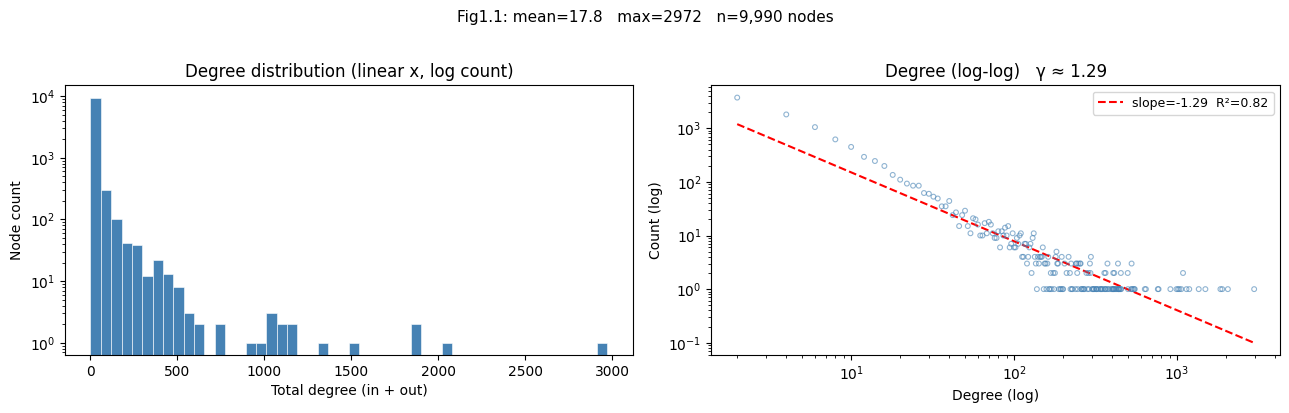

In [6]:
dd = topo.degree_distribution(G)
total_degs = dd["total_degrees"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(total_degs,
             bins=min(50, max(5, len(set(total_degs)))),
             color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Total degree (in + out)")
axes[0].set_ylabel("Node count")
axes[0].set_yscale("log")  # log y so the heavy tail is visible, not crushed by the peak
axes[0].set_title("Degree distribution (linear x, log count)")

unique_deg, counts = np.unique(total_degs, return_counts=True)
if len(unique_deg) >= 3:
    # Open/edge-only markers so data points don't obscure the power-law fit line.
    axes[1].scatter(unique_deg, counts,
                    facecolors="none", edgecolors="steelblue",
                    alpha=0.6, s=12, linewidths=0.8, zorder=3)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Degree (log)")
    axes[1].set_ylabel("Count (log)")
    if len(unique_deg) >= 5:
        mask = (unique_deg > 0) & (counts > 0)
        slope, intercept, r, _, _ = sp_stats.linregress(
            np.log10(unique_deg[mask]), np.log10(counts[mask]))
        x_fit = np.linspace(unique_deg[mask].min(), unique_deg[mask].max(), 100)
        axes[1].plot(x_fit, 10 ** (intercept + slope * np.log10(x_fit)),
                     "r--", lw=1.5, zorder=2, label=f"slope={slope:.2f}  R²={r**2:.2f}")
        axes[1].legend(fontsize=9)
        axes[1].set_title(f"Degree (log-log)   γ ≈ {-slope:.2f}")
    else:
        axes[1].set_title("Degree (log-log)")
else:
    axes[1].text(0.5, 0.5, "Too few unique degrees\nfor log-log plot",
                 ha="center", va="center", transform=axes[1].transAxes, fontsize=11)
    axes[1].set_title("Log-log (insufficient data)")

plt.suptitle(
    f"Fig1.1: mean={np.mean(total_degs):.1f}   max={max(total_degs)}   n={len(total_degs):,} nodes",
    y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## 4 · How much money is in each channel? (capacity)

Capacity is the total bitcoin locked in a channel, and it's public. Like degree, it's **heavy-tailed**: many small channels, a few very large ones. Our snapshot holds **5,637 BTC total**, with a **mean channel of 0.127 BTC but a median of only 0.025 BTC** — the mean sits five times above the median because a small number of large channels (up to the **10 BTC** maximum) drag it up. A log-scale histogram is the only way to see the shape; on a linear axis the giant channels would crush everything else into the first bar.

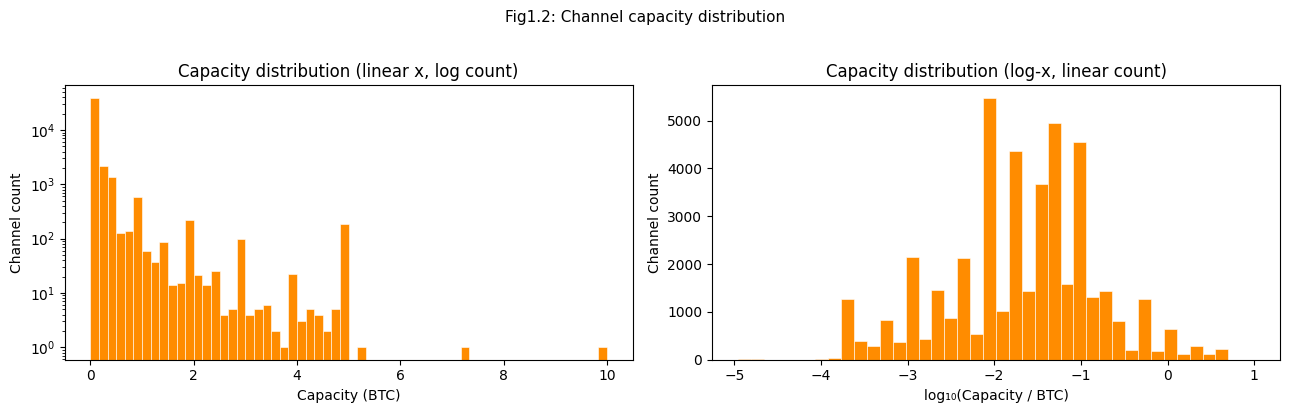

Total capacity : 5636.6586 BTC
Mean           : 0.126664 BTC  (12666 ksat)
Median         : 0.025000 BTC  (2500 ksat)
Max            : 10.0000 BTC  (1000000 ksat)


In [7]:
cd = topo.capacity_distribution(G)
caps_btc = [c / 1e8 for c in cd["capacities"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(caps_btc,
             bins=min(60, max(5, len(caps_btc))),
             color="darkorange", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Capacity (BTC)")
axes[0].set_ylabel("Channel count")
axes[0].set_yscale("log")  # log y so the heavy tail is visible, not crushed by the peak
axes[0].set_title("Capacity distribution (linear x, log count)")

if caps_btc:
    log_caps = [np.log10(c) for c in caps_btc if c > 0]
    axes[1].hist(log_caps,
                 bins=min(40, max(5, len(log_caps))),
                 color="darkorange", edgecolor="white", linewidth=0.4)
    axes[1].set_xlabel("log₁₀(Capacity / BTC)")
    axes[1].set_ylabel("Channel count")
    axes[1].set_title("Capacity distribution (log-x, linear count)")

plt.suptitle("Fig1.2: Channel capacity distribution", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print(f"Total capacity : {cd['total_capacity']/1e8:.4f} BTC")
print(f"Mean           : {cd['mean_capacity']/1e8:.6f} BTC  ({cd['mean_capacity']/1e3:.0f} ksat)")
print(f"Median         : {cd['median_capacity']/1e8:.6f} BTC  ({cd['median_capacity']/1e3:.0f} ksat)")
print(f"Max            : {cd['max_capacity']/1e8:.4f} BTC  ({cd['max_capacity']/1e3:.0f} ksat)")

## 5 · How unequal is that money? (Gini)

The **Gini coefficient** puts one number on the inequality. 0 means every channel is the same size; 1 means a single channel holds everything. It's the same statistic economists use for income inequality. The **Lorenz curve** plots the cumulative share of capacity against the cumulative share of channels (smallest first); the further it bows below the 45° equality line, the more unequal.

Our network scores **Gini = 0.81** — extreme concentration, higher than the income inequality of any country. A small set of well-funded channels carries most of the network's liquidity. For routing, that means large payments effectively depend on a few deep-pocketed hubs.

Gini coefficient (channel capacity): 0.8117
  0 = perfect equality   1 = one channel holds everything


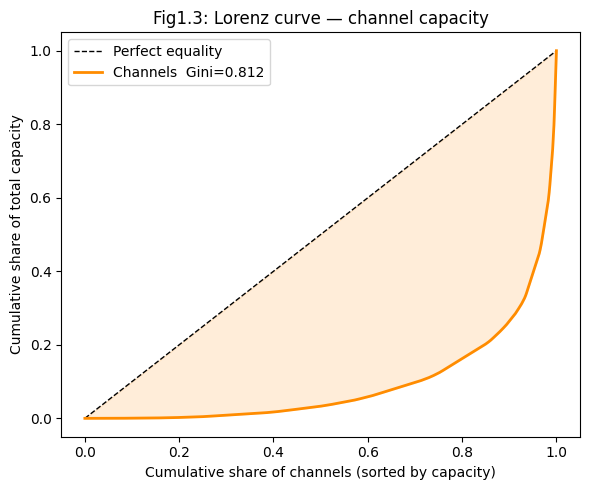

In [8]:
g = cd["gini_capacity"]
print(f"Gini coefficient (channel capacity): {g:.4f}")
print("  0 = perfect equality   1 = one channel holds everything")

caps_sorted = np.sort(cd["capacities"])
n_caps = len(caps_sorted)

if n_caps >= 2:
    cum_pop = np.concatenate([[0], np.arange(1, n_caps + 1) / n_caps])
    cum_cap = np.concatenate([[0], np.cumsum(caps_sorted) / np.sum(caps_sorted)])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect equality")
    ax.plot(cum_pop, cum_cap, color="darkorange", lw=2,
            label=f"Channels  Gini={g:.3f}")
    ax.fill_between(cum_pop, cum_pop, cum_cap, alpha=0.15, color="darkorange")
    ax.set_xlabel("Cumulative share of channels (sorted by capacity)")
    ax.set_ylabel("Cumulative share of total capacity")
    ax.set_title("Fig1.3: Lorenz curve — channel capacity")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6 · Small-world: short paths, local clustering

Lightning is a **small-world** network — the same "six degrees of separation" effect seen in social graphs. Two properties together define it:

- **Short average path length.** Despite ~10,000 nodes, the average shortest path between two of them is just **4.12 hops**, and the longest (the diameter) is **12 hops**. Any node can reach any other in a handful of steps. (Diameter is estimated by sampling random pairs; computing it exactly is too expensive at this scale.)
- **Local clustering.** A **clustering coefficient of 0.114** measures how often a node's two neighbours are themselves connected — how many triangles close. Moderate here: hubs interconnect densely while leaf nodes don't.

Short paths matter directly for payments: fewer hops means lower total fees and — as notebook 04 shows — a higher chance the payment actually succeeds.

In [9]:
clust = topo.clustering_stats(G)
print("Clustering (undirected projection):")
print(f"  Average clustering coefficient: {clust['average_clustering']:.4f}")
print(f"  Transitivity                  : {clust['transitivity']:.4f}")
print()
print("  Clustering: fraction of a node's neighbours that are also neighbours of each other.")
print("  Transitivity: ratio of closed triangles to connected triples (global measure).")

diam = topo.sampled_diameter(G, k=500, seed=42)
print()
print(f"Diameter / path length (sampled {diam['sample_size']} pairs from LCC):")
print(f"  Estimated diameter  : {diam['estimated_diameter']} hops")
print(f"  Average path length : {diam['avg_path_length']:.2f} hops")

Clustering (undirected projection):
  Average clustering coefficient: 0.1139
  Transitivity                  : 0.0784

  Clustering: fraction of a node's neighbours that are also neighbours of each other.
  Transitivity: ratio of closed triangles to connected triples (global measure).



Diameter / path length (sampled 500 pairs from LCC):
  Estimated diameter  : 12 hops
  Average path length : 4.12 hops


## 7 · Key Findings

The table below collects the headline numbers. Here is what they mean together.

**Scale and coverage.** The snapshot holds **9,990 nodes and 44,501 unique channels** — about 57% of the public network's nodes over the crawl window. Large enough that the distributions and centralities are stable, not artifacts of a thin sample.

**It's one connected network.** The largest component contains **100% of nodes** (only 2 stragglers fall outside), so any node can in principle route to any other — routing is a well-posed problem on this graph. The 3 weakly-connected components are the giant core plus two trivial offcuts.

**Hub-dominated, not uniform.** Mean degree is **17.8 channels per node**, but the maximum is **2,972** (ACINQ) and the median sits far below the mean — the signature of a scale-free, hub-and-spoke topology built by preferential attachment. A few nodes carry the connectivity; most are leaves with one or two channels.

**Capital is heavily concentrated.** Total capacity is **5,637 BTC**, but its spread is extreme: a **Gini of 0.81**, higher than the income inequality of any country. A small set of well-funded channels holds most of the routable liquidity, which is why large payments depend on a handful of deep-pocketed hubs (notebook 04).

**It's a small world.** Despite ~10,000 nodes, the **average shortest path is 4.12 hops** and the **diameter is 12** — any two nodes are a few steps apart. Local **clustering is 0.114** (transitivity 0.078): moderate triangle density, concentrated among the interconnected hubs. Short paths are what make Lightning payments cheap and — as notebook 04 shows — more likely to succeed.

**Why this matters for the analyses that follow.** The same hub structure recurs in every later notebook: it makes expensive global metrics cheap to approximate (notebook 02, where 1 pivot already matches exact betweenness), gives short reliable routes through a few well-capitalised nodes (notebook 03), and concentrates both routing power and systemic risk in a small core — the recurring constraint an LSP (Lightning Service Provider) operator has to design around.

In [10]:
_n_ch = len({data.get("channel_id") for _, _, data in G.edges(data=True)})
summary = [
    ("Nodes",                    f"{G.number_of_nodes():,}"),
    ("Channels (unique)",        f"{_n_ch:,}"),
    ("LCC fraction",             f"{cs['fraction_in_lcc']*100:.1f}%"),
    ("Weakly conn. components",  f"{cs['num_weakly_connected']:,}"),
    ("Mean total degree",        f"{np.mean(dd['total_degrees']):.1f}"),
    ("Max total degree",         f"{max(dd['total_degrees'])}"),
    ("Total capacity (BTC)",     f"{cd['total_capacity']/1e8:.4f}"),
    ("Gini (capacity)",          f"{cd['gini_capacity']:.3f}"),
    ("Avg clustering coeff.",    f"{clust['average_clustering']:.4f}"),
    ("Transitivity",             f"{clust['transitivity']:.4f}"),
    ("Est. diameter (hops)",     f"{diam['estimated_diameter']}"),
    ("Avg path length (hops)",   f"{diam['avg_path_length']:.2f}"),
]
print(pd.DataFrame(summary, columns=["Metric", "Value"]).to_string(index=False))

                 Metric     Value
                  Nodes     9,990
      Channels (unique)    44,501
           LCC fraction    100.0%
Weakly conn. components         3
      Mean total degree      17.8
       Max total degree      2972
   Total capacity (BTC) 5636.6586
        Gini (capacity)     0.812
  Avg clustering coeff.    0.1139
           Transitivity    0.0784
   Est. diameter (hops)        12
 Avg path length (hops)      4.12
